# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A linear model is linear in its parameters (coefficients). This means the coefficients enter the model only through addition and multiplication. The model is written as a linear combination (a weighted sum) of the variables. Even if the variables themselves are nonlinear (like $x^2$ or $\log(x)$), the model is still considered linear as long as it is linear with respect to the coefficients.

2. A dummy variable coefficient shows the difference in the outcome compared to a reference group. When we include an intercept and drop one category (to avoid the "dummy variable trap"), the intercept represents the mean of the reference group. Each dummy coefficient measures how much that specific group differs from the reference group on average.

3. Linear regression can be used for classification by applying a cutoff like 0.5. However, it is not a good choice because predictions are not restricted between 0 and 1, which can produce invalid probability values. Also, linear regression is very sensitive to outliers, which can shift the decision boundary and lead to poor results.

4. Overfitting happens when a model is too complex and learns random noise instead of the real pattern. The model fits the training data very well but performs poorly on new, unseen data. This usually means the model has high variance, meaning it is too sensitive to the specific data it was trained on.

5. Multicollinearity occurs when independent variables are highly correlated and explain the same variation in the outcome. In a two-stage sense, these variables "compete" to explain the same signal, leaving very little unique variation for each variable. This makes the coefficients unstable and noisy, leading to high model variance.

6. Linear models cannot capture nonlinear patterns directly in their original form. However, we can include polynomial terms (like $x^2$) or interaction terms (like $x_1 \cdot x_2$) to handle this. These transformations allow the model to fit more complex, curvy relationships while still staying within a linear framework.

7. The slope coefficient shows how much the outcome changes when the predictor increases by one unit, holding all other variables constant. This interpretation assumes that the model "controls" for the effects of the other variables included in the regression.

8. A train/test split divides the data only once, so the result depends heavily on that single random split. In contrast, k-fold cross validation splits the data into $k$ parts and repeats the process $k$ times. This uses all the data for both training and validation, providing a more reliable and stable estimate of model performance.

9. The value of $k$ is chosen to balance computation time and stability. Common choices are 5 or 10, as they usually provide a good balance between bias and variance. Larger values of $k$ give more stable results but take much more time to compute.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [32]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Q1_clean.csv')
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [34]:
df = df.rename(columns={
    'Price': 'price',
    'Review Scores Rating': 'review_score',
    'Neighbourhood ': 'neighbourhood'
})

In [35]:
group_means = df.groupby('neighbourhood')[['price', 'review_score']].mean()
group_means

,price,review_score
neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


On average, Manhattan has the highest price among all neighbourhoods. The average review scores are similar across neighbourhoods, with only small differences.

In [36]:
df.columns

Index(['price', 'review_score', 'neighbourhood', 'Property Type', 'Room Type'], dtype='object')

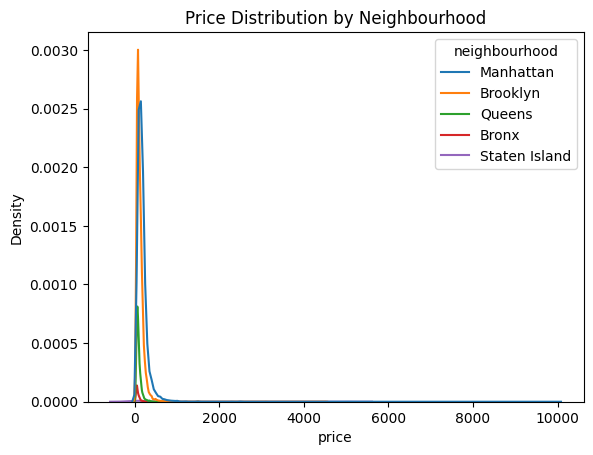

In [37]:
sns.kdeplot(data=df, x='price', hue='neighbourhood')
plt.title('Price Distribution by Neighbourhood')
plt.show()

The price distribution is highly right-skewed, with a long tail of very expensive listings. Most listings are concentrated at lower price levels, but there are a few very high-priced observations that stretch the distribution.

On average, Manhattan tends to have higher prices compared to other neighbourhoods, while boroughs like the Bronx and Staten Island have lower price distributions.

In [38]:
df['log_price'] = np.log(df['price'])

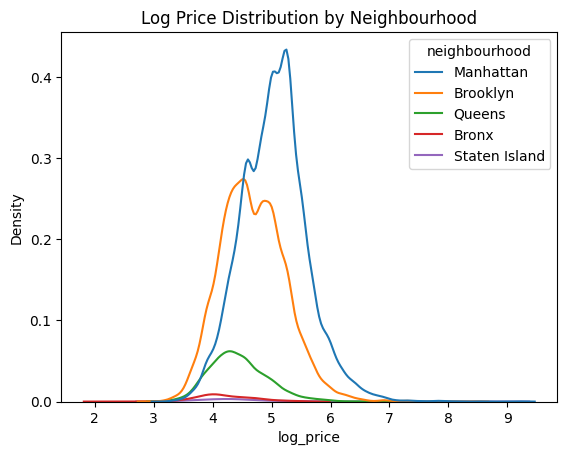

In [39]:
sns.kdeplot(data=df, x='log_price', hue='neighbourhood')
plt.title('Log Price Distribution by Neighbourhood')
plt.show()


After taking the log of price, the distribution becomes more symmetric and less skewed. This makes it easier to compare the distributions across neighbourhoods. Manhattan still shows higher prices compared to other neighbourhoods even after the log transformation.

In [40]:
X = pd.get_dummies(df['neighbourhood'], drop_first=True)
y = df['price']

In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print(pd.DataFrame({
    'variable': X.columns,
    'coefficient': model.coef_
}))

Intercept: 75.27649769585331
        variable  coefficient
0       Brooklyn    52.470881
1      Manhattan   108.387789
2         Queens    21.580735
3  Staten Island    70.890169


The intercept represents the average price in the Bronx, which is about 75.3.

The coefficient for Brooklyn shows that, on average, prices in Brooklyn are about 52.4 higher than in the Bronx.

The coefficient for Manhattan shows that, on average, prices in Manhattan are about 108.4 higher than in the Bronx.

The coefficient for Queens shows that, on average, prices in Queens are about 21.6 higher than in the Bronx.

The coefficient for Staten Island shows that, on average, prices in Staten Island are about 70.9 higher than in the Bronx.

I dropped the first category when creating dummy variables, so the model uses a reference group.

These coefficients match the differences in average prices across neighbourhoods from part 1. When we add each coefficient to the intercept (the Bronx average), we recover the average price for each neighbourhood. This shows that the coefficients represent differences from the reference group, and the conditional group means are given by the intercept plus these differences.


In [42]:
from sklearn.linear_model import LinearRegression

X = df[['review_score']]
y = df['price']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 60.878390657123546
Slope: 1.0208266022674763


The slope coefficient shows that, on average, a one-unit increase in review score is associated with about a 1.02 increase in price. This means that listings with higher review scores tend to have slightly higher prices, although the effect is relatively small.

In [43]:
X = pd.concat([pd.get_dummies(df['neighbourhood'], drop_first=True), df[['review_score']]], axis=1)
y = df['price']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print(pd.DataFrame({
    'variable': X.columns,
    'coefficient': model.coef_
}))

Intercept: -23.812561011672244
        variable  coefficient
0       Brooklyn    51.704240
1      Manhattan   108.228737
2         Queens    21.694600
3  Staten Island    71.766552
4   review_score     1.081116


The slope on review score increases slightly from about 1.02 to 1.08 after including neighbourhood. This suggests that, holding neighbourhood constant, higher review scores are still associated with higher prices, and the effect becomes slightly stronger.

The neighbourhood coefficients remain similar to before, meaning that differences in average prices across neighbourhoods are still large and persistent. This shows that both neighbourhood and review score independently contribute to price.

In [44]:
X = pd.concat([
    pd.get_dummies(df['neighbourhood'], drop_first=True),
    df[['review_score']]
], axis=1)


for col in ['Brooklyn', 'Manhattan', 'Queens', 'Staten Island']:
    X[f'{col}_x_score'] = X[col] * df['review_score']

y = df['price']

model = LinearRegression()
model.fit(X, y)

print(pd.DataFrame({
    'variable': X.columns,
    'coefficient': model.coef_
}))

                variable  coefficient
0               Brooklyn   -16.392990
1              Manhattan    41.315429
2                 Queens    28.259701
3          Staten Island  2963.071040
4           review_score     0.574311
5       Brooklyn_x_score     0.741165
6      Manhattan_x_score     0.729703
7         Queens_x_score    -0.072294
8  Staten Island_x_score   -31.831748


The slopes are not similar across neighbourhoods. The interaction terms show that the effect of review score varies across neighbourhoods, with some areas having stronger or weaker relationships.

In [45]:
from sklearn.model_selection import cross_val_score

# Model 4: review_score only
X4 = df[['review_score']]
y = df['price']

model4 = LinearRegression()
cv4 = cross_val_score(model4, X4, y, cv=10, scoring='neg_mean_squared_error')


# Model 5: neighbourhood + review_score
X5 = pd.concat([
    pd.get_dummies(df['neighbourhood'], drop_first=True),
    df[['review_score']]
], axis=1)

model5 = LinearRegression()
cv5 = cross_val_score(model5, X5, y, cv=10, scoring='neg_mean_squared_error')


# Model 6: interaction model
X6 = X5.copy()
for col in ['Brooklyn', 'Manhattan', 'Queens', 'Staten Island']:
    X6[f'{col}_x_score'] = X6[col] * df['review_score']

model6 = LinearRegression()
cv6 = cross_val_score(model6, X6, y, cv=10, scoring='neg_mean_squared_error')


print("Model 4 MSE:", -cv4.mean())
print("Model 5 MSE:", -cv5.mean())
print("Model 6 MSE:", -cv6.mean())

Model 4 MSE: 22092.66808869053
Model 5 MSE: 21095.14231724225
Model 6 MSE: 21321.05846668689


Model 5 has the lowest mean squared error, indicating that including neighbourhood improves prediction compared to using review score alone.

Model 6 has a slightly higher error than Model 5, suggesting that adding interaction terms does not improve performance and may introduce unnecessary complexity.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [46]:
df = pd.read_csv('./data/cars_hw.csv')

df['Price'].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


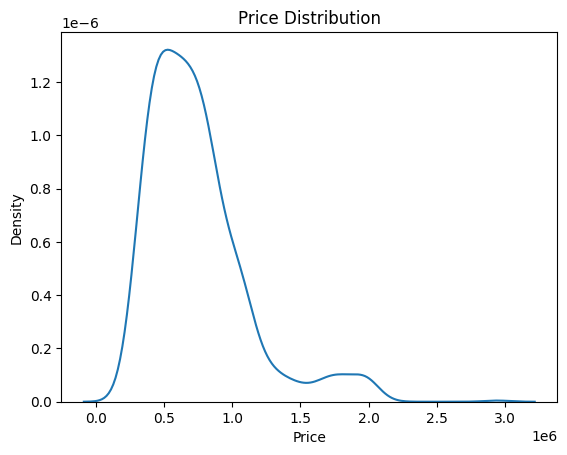

In [47]:
sns.kdeplot(data=df, x='Price')
plt.title('Price Distribution')
plt.show()

The price distribution is right-skewed, with a long tail of very expensive cars. Most cars are concentrated at lower price levels, while a small number of high-priced cars extend the distribution to the right. The large difference between the mean and the maximum price also suggests the presence of high-priced outliers.

In [48]:
df.groupby('Body_Type')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


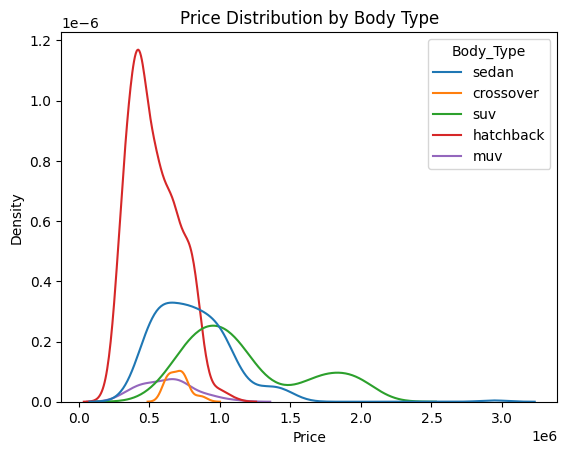

In [49]:
sns.kdeplot(data=df, x='Price', hue='Body_Type')
plt.title('Price Distribution by Body Type')
plt.show()

On average, SUVs have the highest prices, followed by sedans, while hatchbacks have the lowest prices.

SUVs also have the largest variance in prices, as shown by their wide spread and high standard deviation. In contrast, hatchbacks have the smallest variance, with prices more tightly concentrated at lower levels.

In [50]:
X = df[['Seating_Capacity']]
y = df['Price']

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])

Slope: 59267.99803672175


The slope coefficient shows that, on average, a one-unit increase in seating capacity is associated with about a 59,268 increase in price.

This means that cars with more seats tend to be more expensive, and the effect is relatively large.

In [51]:
X_cat = pd.get_dummies(df['Seating_Capacity'], drop_first=True)
model = LinearRegression()
model.fit(X_cat, y)

print(pd.DataFrame({
    'variable': X_cat.columns,
    'coefficient': model.coef_
}))

   variable   coefficient
0         5  5.464839e+05
1         6  1.456000e+06
2         7  7.359487e+05
3         8  2.718000e+05


When seating capacity is treated as a categorical variable, the price differences across seat counts are not perfectly linear.

For example, the increase in price from 5 to 6 seats is much larger than from 7 to 8 seats, and some categories show smaller or irregular changes.

This suggests that the relationship between seating capacity and price is not strictly linear.

In [52]:
df['Age'] = 2025 - df['Make_Year']

In [53]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score

y = df['Price']

results = []

for d in range(1, 6):
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(df[['Age']])

    model = LinearRegression()
    scores = cross_val_score(model, X_poly, y, cv=10, scoring='neg_mean_squared_error')

    results.append((d, -scores.mean()))

results

[(1, np.float64(100295370079.45541)),
 (2, np.float64(100814620596.42154)),
 (3, np.float64(100380163091.9189)),
 (4, np.float64(100474431121.11421)),
 (5, np.float64(100131346193.24283))]

The lowest mean squared error is achieved with a polynomial degree of 5.

This suggests that a higher-order polynomial provides a slightly better fit to the relationship between age and price. However, the differences across models are small, indicating that increasing complexity does not lead to a large improvement in performance.

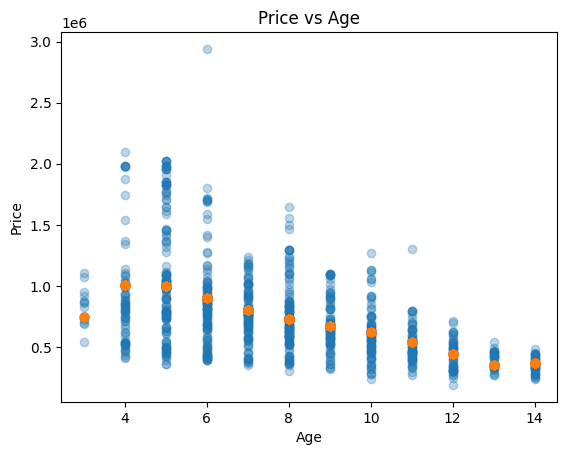

In [54]:
poly = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly.fit_transform(df[['Age']])

model = LinearRegression()
model.fit(X_poly, df['Price'])

df['pred_price'] = model.predict(X_poly)

# scatter + line
plt.scatter(df['Age'], df['Price'], alpha=0.3)
plt.scatter(df['Age'], df['pred_price'], alpha=0.3)
plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Price vs Age')
plt.show()

The model captures the general pattern in the data, where car prices decrease as age increases.

However, the model does not perfectly fit the data. There is still a lot of variation in prices, especially for newer cars, which suggests that age alone does not fully explain price.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [55]:
df = pd.read_csv('heart_hw.csv')
df.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [56]:
df.columns

Index(['Unnamed: 0', 'age', 'transplant', 'y'], dtype='object')

In [57]:
control_survival = df.loc[df['transplant'] == 'control', 'y'].mean()
treatment_survival = df.loc[df['transplant'] == 'treatment', 'y'].mean()
ate = treatment_survival - control_survival

print("Control survival:", control_survival)
print("Treatment survival:", treatment_survival)
print("ATE:", ate)

Control survival: 0.11764705882352941
Treatment survival: 0.34782608695652173
ATE: 0.23017902813299232


The survival rate in the control group is about 0.118, and the survival rate in the treatment group is about 0.348.

The average treatment effect (ATE) is about 0.230. This means that receiving a transplant is associated with about a 23 percentage point increase in the probability of surviving for three years.

In [58]:
X = pd.get_dummies(df['transplant'], drop_first=True)
y = df['y']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 0.1176470588235293
Coefficient: 0.23017902813299249


The intercept represents the survival rate in the control group, which is about 0.118.

The coefficient on the transplant variable is about 0.230, which represents the difference in survival rates between the treatment and control groups.

This matches the ATE from part 1, meaning that the regression is reproducing the same difference in average outcomes between the two groups.

In [59]:
X = pd.concat([
    pd.get_dummies(df['transplant'], drop_first=True),
    df[['age']]
], axis=1)

y = df['y']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print(pd.DataFrame({
    'variable': X.columns,
    'coefficient': model.coef_
}))

Intercept: 0.7019569721740947
    variable  coefficient
0  treatment     0.264702
1        age    -0.013607


The coefficient on transplant increases from about 0.230 to about 0.265 after controlling for age. This means that, holding age constant, the estimated effect of a transplant on survival becomes slightly larger.

The intercept represents the predicted probability of survival for a control patient when age is zero, while the coefficient on age shows that, on average, survival decreases as age increases.

Compared to the ATE from part 1, this model suggests that the effect of a transplant is not constant across all ages. The ATE may overestimate the effect for some ages and underestimate it for others, because it does not account for differences in age.

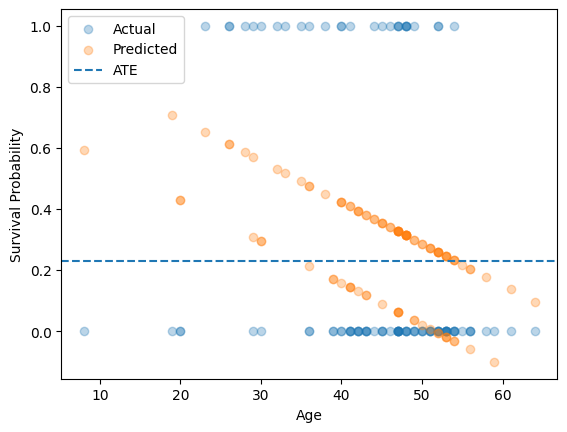

In [60]:

df['pred'] = model.predict(X)


plt.scatter(df['age'], df['y'], alpha=0.3, label='Actual')


plt.scatter(df['age'], df['pred'], alpha=0.3, label='Predicted')

plt.axhline(y=ate, linestyle='--', label='ATE')

plt.xlabel('Age')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

The model shows that predicted survival decreases as age increases.

The ATE is constant across all ages, while the model’s predicted survival probabilities vary with age. This means that the ATE does not capture how the effect of a transplant changes with age, and it may overestimate or underestimate the effect depending on the age group.

In [61]:
X = pd.concat([
    pd.get_dummies(df['transplant'], drop_first=True),
    df[['age']]
], axis=1)

# interaction term
X['treatment_x_age'] = X['treatment'] * df['age']

y = df['y']

model = LinearRegression()
model.fit(X, y)

print(pd.DataFrame({
    'variable': X.columns,
    'coefficient': model.coef_
}))

          variable  coefficient
0        treatment     0.907751
1              age    -0.005524
2  treatment_x_age    -0.014591


Allowing age and transplant to interact changes the predictions by making the effect of a transplant depend on age.

The negative interaction term shows that the effect of a transplant decreases as age increases. This means that the benefit of a transplant is larger for younger patients and smaller for older patients.

This reveals a clear pattern that the impact of treatment is not constant, but varies with age.

In [62]:
from sklearn.model_selection import cross_val_score

y = df['y']

# Model 1: transplant only
X1 = pd.get_dummies(df['transplant'], drop_first=True)
m1 = LinearRegression()
cv1 = cross_val_score(m1, X1, y, cv=10, scoring='neg_mean_squared_error')

# Model 2: transplant + age
X2 = pd.concat([X1, df[['age']]], axis=1)
m2 = LinearRegression()
cv2 = cross_val_score(m2, X2, y, cv=10, scoring='neg_mean_squared_error')

# Model 3: interaction
X3 = X2.copy()
X3['treatment_x_age'] = X3['treatment'] * df['age']
m3 = LinearRegression()
cv3 = cross_val_score(m3, X3, y, cv=10, scoring='neg_mean_squared_error')

print("Model 1:", -cv1.mean())
print("Model 2:", -cv2.mean())
print("Model 3:", -cv3.mean())

Model 1: 0.20970277289824915
Model 2: 0.19922806049232317
Model 3: 0.19609811380122735


The model with transplant and age has a lower prediction error than the model with transplant only, showing that including age improves prediction.

The interaction model has the lowest error, which suggests that allowing the effect of transplant to vary with age further improves predictive accuracy.

One concern is that the model may prioritize younger patients, since the estimated benefit of a transplant is larger for them. This could be unfair to older patients.

Another concern is that the model is based on observational data, so the estimated effects may not be truly causal. This could lead to incorrect decisions about who should receive a transplant.

There is also a concern about missing variables, since important health factors may not be included in the model, which could bias the results.

The model focuses only on survival probability and does not consider fairness or differences in life years gained.